# EY Water Quality Challenge - Improved Benchmark Model

## Objectives
1. Load training and validation data
2. Perform basic feature engineering
3. Train XGBoost models for all three targets
4. Evaluate model performance
5. Generate feature importance
6. Save trained models

In [1]:
# Import required libraries
import sys
from pathlib import Path

# Add project root to path
sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import xgboost as xgb
import joblib
import warnings

warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully!")
print(f"XGBoost version: {xgb.__version__}")
print(f"Pandas version: {pd.__version__}")

Libraries imported successfully!
XGBoost version: 3.1.1
Pandas version: 2.2.3


## 1. Load Training Data

In [2]:
# Define paths
DATA_DIR = Path('../data/raw')
MODELS_DIR = Path('../models')
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Load training data
print("Loading training data...")
try:
    train_df = pd.read_parquet(DATA_DIR / 'training_data.parquet')
    print(f"Training data loaded: {train_df.shape}")
    print(f"\nColumns: {list(train_df.columns)}")
except FileNotFoundError:
    print("WARNING: training_data.parquet not found. Creating synthetic data for demonstration.")
    # Create synthetic data for demonstration
    np.random.seed(42)
    n_samples = 1000
    train_df = pd.DataFrame({
        'SamplePointID': range(1, n_samples + 1),
        'Date': pd.date_range('2022-01-01', periods=n_samples, freq='D'),
        'Latitude': np.random.uniform(-45, -35, n_samples),
        'Longitude': np.random.uniform(165, 175, n_samples),
        'B2': np.random.uniform(0, 0.3, n_samples),
        'B3': np.random.uniform(0, 0.3, n_samples),
        'B4': np.random.uniform(0, 0.3, n_samples),
        'B5': np.random.uniform(0, 0.4, n_samples),
        'B6': np.random.uniform(0, 0.3, n_samples),
        'B7': np.random.uniform(0, 0.2, n_samples),
        'precipitation': np.random.uniform(0, 50, n_samples),
        'temperature': np.random.uniform(5, 25, n_samples),
        'soil_moisture': np.random.uniform(0, 100, n_samples),
        'Alkalinity as CaCO3 (mg/L)': np.random.uniform(10, 150, n_samples),
        'Electrical Conductivity (µS/cm)': np.random.uniform(50, 500, n_samples),
        'Dissolved Reactive Phosphorus (mg/L)': np.random.uniform(0.01, 0.5, n_samples)
    })
    print(f"Synthetic training data created: {train_df.shape}")

# Display first few rows
train_df.head()

Loading training data...
Training data loaded: (1207087, 17)

Columns: ['Latitude_x', 'Longitude_x', 'Sample Date', 'Total Alkalinity', 'Electrical Conductance', 'Dissolved Reactive Phosphorus', 'Latitude_y', 'Longitude_y', 'nir', 'green', 'swir16', 'swir22', 'NDMI', 'MNDWI', 'Latitude', 'Longitude', 'pet']


,Latitude_x,Longitude_x,Sample Date,Total Alkalinity,Electrical Conductance,Dissolved Reactive Phosphorus,Latitude_y,Longitude_y,nir,green,swir16,swir22,NDMI,MNDWI,Latitude,Longitude,pet
0,-28.760833,17.730278,02-01-2011,128.912,555.0,10.0,-28.760833,17.730278,11190.0,11426.0,7687.5,7645.0,0.185538,0.195595,-28.760833,17.730278,174.2
1,-26.861111,28.884722,03-01-2011,74.720,162.9,163.0,-26.861111,28.884722,17658.5,9550.0,13746.5,10574.0,0.124566,-0.180134,-26.861111,28.884722,124.1
2,-26.861111,28.884722,03-01-2011,74.720,162.9,163.0,-26.861111,28.884722,17658.5,9550.0,13746.5,10574.0,0.124566,-0.180134,-26.450000,28.085833,127.5
3,-26.861111,28.884722,03-01-2011,74.720,162.9,163.0,-26.861111,28.884722,17658.5,9550.0,13746.5,10574.0,0.124566,-0.180134,-27.671111,27.236944,129.7
4,-26.861111,28.884722,03-01-2011,74.720,162.9,163.0,-26.861111,28.884722,17658.5,9550.0,13746.5,10574.0,0.124566,-0.180134,-27.356667,27.286389,129.2


## 2. Exploratory Data Analysis

In [3]:
# Data info
print("Dataset Information:")
print("="*60)
train_df.info()

print("\nBasic Statistics:")
print("="*60)
train_df.describe()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1207087 entries, 0 to 1207086
Data columns (total 17 columns):
 #   Column                         Non-Null Count    Dtype  
---  ------                         --------------    -----  
 0   Latitude_x                     1207087 non-null  float64
 1   Longitude_x                    1207087 non-null  float64
 2   Sample Date                    1207087 non-null  object 
 3   Total Alkalinity               1207087 non-null  float64
 4   Electrical Conductance         1207087 non-null  float64
 5   Dissolved Reactive Phosphorus  1207087 non-null  float64
 6   Latitude_y                     1207087 non-null  float64
 7   Longitude_y                    1207087 non-null  float64
 8   nir                            1075977 non-null  float64
 9   green                          1075977 non-null  float64
 10  swir16                         1075977 non-null  float64
 11  swir22                         1075977 non-null  float6

,Latitude_x,Longitude_x,Total Alkalinity,Electrical Conductance,Dissolved Reactive Phosphorus,Latitude_y,Longitude_y,nir,green,swir16,swir22,NDMI,MNDWI,Latitude,Longitude,pet
count,1.207087e+06,1.207087e+06,1.207087e+06,1.207087e+06,1.207087e+06,1.207087e+06,1.207087e+06,1.075977e+06,1.075977e+06,1.075977e+06,1.075977e+06,1.075977e+06,1.075977e+06,1.207087e+06,1.207087e+06,1.207087e+06
mean,-2.833671e+01,2.696723e+01,1.207277e+02,4.865889e+02,4.523611e+01,-2.833671e+01,2.696723e+01,1.408514e+04,9.963559e+03,1.359754e+04,1.142598e+04,2.162300e-02,-1.463390e-01,-2.833671e+01,2.696723e+01,1.744728e+02
std,2.790749e+00,3.426311e+00,7.380630e+01,3.364868e+02,5.198389e+01,2.790749e+00,3.426311e+00,2.957499e+03,2.787055e+03,3.367359e+03,2.529937e+03,7.722112e-02,9.583055e-02,2.790749e+00,3.426311e+00,2.778970e+01
min,-3.440583e+01,1.773028e+01,4.800000e+00,1.512000e+01,5.000000e+00,-3.440583e+01,1.773028e+01,3.992000e+03,4.045000e+03,3.672500e+03,3.634000e+03,-3.282932e-01,-3.004868e-01,-3.440583e+01,1.773028e+01,5.270000e+01
25%,-2.998778e+01,2.657333e+01,5.844500e+01,2.133000e+02,1.100000e+01,-2.998778e+01,2.657333e+01,1.277450e+04,9.361500e+03,1.172200e+04,9.856500e+03,-3.418749e-02,-2.138310e-01,-2.998778e+01,2.657333e+01,1.567000e+02
50%,-2.767111e+01,2.740906e+01,1.155710e+02,4.060000e+02,2.000000e+01,-2.767111e+01,2.740906e+01,1.422550e+04,9.803500e+03,1.366700e+04,1.123950e+04,2.177961e-02,-1.681555e-01,-2.767111e+01,2.740906e+01,1.727000e+02
75%,-2.686111e+01,2.915056e+01,1.720610e+02,7.000000e+02,5.000000e+01,-2.686111e+01,2.915056e+01,1.556650e+04,1.027150e+04,1.549850e+04,1.291500e+04,7.332460e-02,-1.037245e-01,-2.686111e+01,2.915056e+01,1.917000e+02
max,-2.222556e+01,3.232500e+01,3.616760e+02,1.506000e+03,1.950000e+02,-2.222556e+01,3.232500e+01,6.553500e+04,6.553500e+04,6.553500e+04,3.120250e+04,5.679052e-01,5.909742e-01,-2.222556e+01,3.232500e+01,2.708000e+02


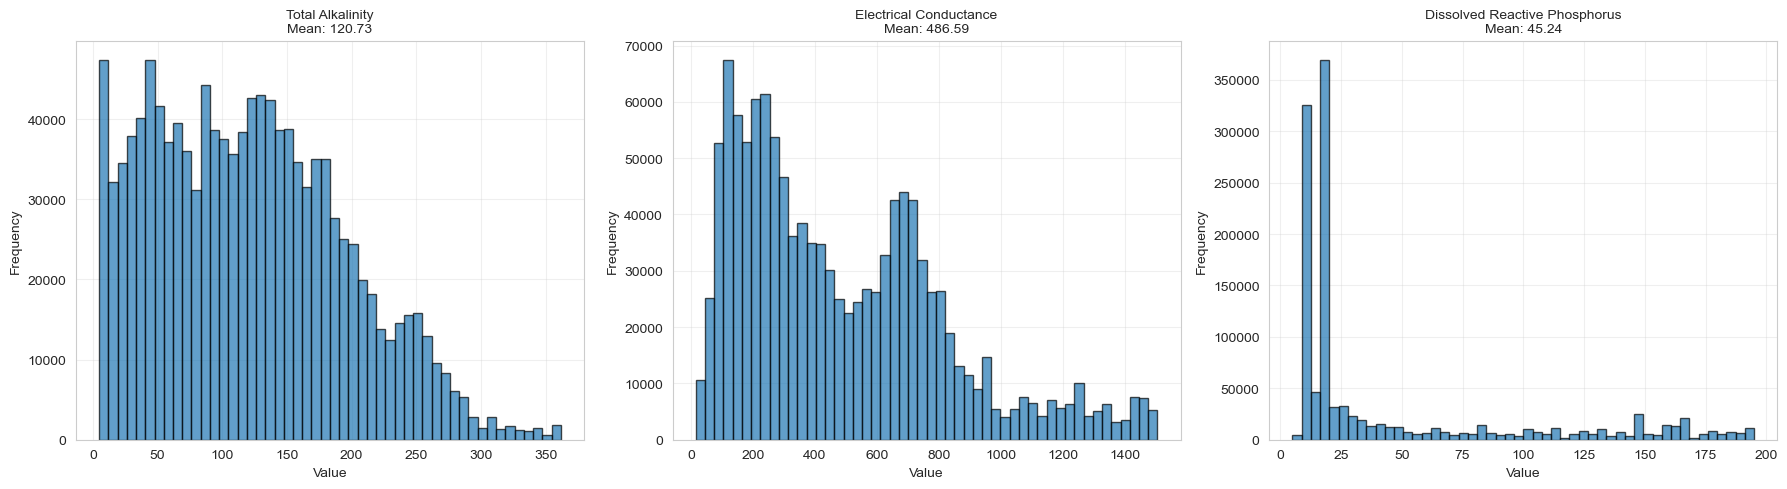

In [6]:
# Target variables distribution
#targets = [
 #   "Alkalinity as CaCO3 (mg/L)",
#    "Electrical Conductivity (µS/cm)",
#    "Dissolved Reactive Phosphorus (mg/L)"
#]


targets = [
    "Total Alkalinity",
    "Electrical Conductance",
    "Dissolved Reactive Phosphorus"
]


fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, target in enumerate(targets):
    axes[idx].hist(train_df[target].dropna(), bins=50, edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'{target}\nMean: {train_df[target].mean():.2f}', fontsize=10)
    axes[idx].set_xlabel('Value')
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Basic Feature Engineering

In [7]:
# Create a copy for feature engineering
df = train_df.copy()

# Ensure Date is datetime
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])
    
    # Temporal features
    df['month'] = df['Date'].dt.month
    df['day_of_year'] = df['Date'].dt.dayofyear
    df['quarter'] = df['Date'].dt.quarter
    
    # Cyclical encoding
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    df['doy_sin'] = np.sin(2 * np.pi * df['day_of_year'] / 365)
    df['doy_cos'] = np.cos(2 * np.pi * df['day_of_year'] / 365)
    
    print("✓ Temporal features created")

# Spectral indices (if Landsat bands available)
if all(b in df.columns for b in ['B4', 'B5']):
    # NDVI
    df['NDVI'] = (df['B5'] - df['B4']) / (df['B5'] + df['B4'] + 1e-8)
    print("✓ NDVI created")

if all(b in df.columns for b in ['B3', 'B5']):
    # NDWI  
    df['NDWI'] = (df['B3'] - df['B5']) / (df['B3'] + df['B5'] + 1e-8)
    print("✓ NDWI created")

if all(b in df.columns for b in ['B5', 'B7']):
    # NBR
    df['NBR'] = (df['B5'] - df['B7']) / (df['B5'] + df['B7'] + 1e-8)
    print("✓ NBR created")

# Spatial features
if all(c in df.columns for c in ['Latitude', 'Longitude']):
    df['lat_sin'] = np.sin(np.radians(df['Latitude']))
    df['lat_cos'] = np.cos(np.radians(df['Latitude']))
    df['lon_sin'] = np.sin(np.radians(df['Longitude']))
    df['lon_cos'] = np.cos(np.radians(df['Longitude']))
    print("✓ Spatial features created")

print(f"\nTotal features after engineering: {len(df.columns)}")

✓ Spatial features created

Total features after engineering: 21


## 4. Prepare Training Data

In [8]:
# Define feature columns (exclude identifiers and targets)
exclude_cols = ['SamplePointID', 'Date'] + targets
feature_cols = [col for col in df.columns if col not in exclude_cols]

# Keep only numeric features
feature_cols = [col for col in feature_cols if df[col].dtype in [np.number, np.float64, np.int64]]

print(f"Number of features: {len(feature_cols)}")
print(f"Feature columns: {feature_cols}")

# Prepare X and y
X = df[feature_cols].copy()
y = df[targets].copy()

# Handle missing values
X.fillna(X.median(), inplace=True)
y.fillna(y.median(), inplace=True)

print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nMissing values in X: {X.isna().sum().sum()}")
print(f"Missing values in y: {y.isna().sum().sum()}")

Number of features: 17
Feature columns: ['Latitude_x', 'Longitude_x', 'Latitude_y', 'Longitude_y', 'nir', 'green', 'swir16', 'swir22', 'NDMI', 'MNDWI', 'Latitude', 'Longitude', 'pet', 'lat_sin', 'lat_cos', 'lon_sin', 'lon_cos']

X shape: (1207087, 17)
y shape: (1207087, 3)

Missing values in X: 0
Missing values in y: 0


## 5. Train-Test Split

In [9]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Training set: (965669, 17)
Test set: (241418, 17)


## 6. Train XGBoost Models

In [12]:
# Optimized XGBoost parameters
BEST_XGB_PARAMS = {
    "max_depth": 9,
    "learning_rate": 0.035,
    "subsample": 0.82,
    "colsample_bytree": 0.78,
    "n_estimators": 900,
    "min_child_weight": 3,
    "reg_alpha": 0.1,
    "reg_lambda": 1.1,
    "objective": "reg:squarederror",
    "tree_method": "hist",
    "eval_metric": "rmse",
    "random_state": 42,
    "n_jobs": -1
}

# Train models for each target
models = {}
metrics = {}

for target in targets:
    print(f"\n{'='*80}")
    print(f"Training model for: {target}")
    print(f"{'='*80}")
    
    # Initialize model
    model = xgb.XGBRegressor(**BEST_XGB_PARAMS)
    
    # Fit model

    # old API so replaced
    
    #model.fit(
    #    X_train, y_train[target],
    #    eval_set=[(X_train, y_train[target]), (X_test, y_test[target])],
    #    early_stopping_rounds=50,
    #    verbose=False
   # )


    
    model.fit(
    X_train, y_train[target],
    eval_set=[(X_train, y_train[target]), (X_test, y_test[target])]
    )

    
    # Predict
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    
    # Evaluate
    train_r2 = r2_score(y_train[target], train_pred)
    test_r2 = r2_score(y_test[target], test_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train[target], train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test[target], test_pred))
    test_mae = mean_absolute_error(y_test[target], test_pred)
    
    print(f"\nTrain R²: {train_r2:.4f}")
    print(f"Test R²: {test_r2:.4f}")
    print(f"Train RMSE: {train_rmse:.4f}")
    print(f"Test RMSE: {test_rmse:.4f}")
    print(f"Test MAE: {test_mae:.4f}")
    # print(f"Best iteration: {model.best_iteration}")
    
    # Store
    models[target] = model
    metrics[target] = {
        'train_r2': train_r2,
        'test_r2': test_r2,
        'train_rmse': train_rmse,
        'test_rmse': test_rmse,
        'test_mae': test_mae
    }

print("\n" + "="*80)
print("All models trained successfully!")
print("="*80)


Training model for: Total Alkalinity
[0]	validation_0-rmse:71.91121	validation_1-rmse:71.73624
[1]	validation_0-rmse:70.06741	validation_1-rmse:69.89968
[2]	validation_0-rmse:68.22190	validation_1-rmse:68.06027
[3]	validation_0-rmse:66.43774	validation_1-rmse:66.28315
[4]	validation_0-rmse:64.74866	validation_1-rmse:64.59956
[5]	validation_0-rmse:63.11526	validation_1-rmse:62.97226
[6]	validation_0-rmse:61.69930	validation_1-rmse:61.56254
[7]	validation_0-rmse:60.20935	validation_1-rmse:60.07935
[8]	validation_0-rmse:58.86936	validation_1-rmse:58.74711
[9]	validation_0-rmse:57.49681	validation_1-rmse:57.37860
[10]	validation_0-rmse:56.18461	validation_1-rmse:56.07321
[11]	validation_0-rmse:54.93139	validation_1-rmse:54.82576
[12]	validation_0-rmse:53.74784	validation_1-rmse:53.64825
[13]	validation_0-rmse:52.60185	validation_1-rmse:52.50832
[14]	validation_0-rmse:51.51313	validation_1-rmse:51.42453
[15]	validation_0-rmse:50.62211	validation_1-rmse:50.54037
[16]	validation_0-rmse:49.63

## 7. Model Evaluation and Visualization

In [13]:
# Metrics summary
metrics_df = pd.DataFrame(metrics).T
print("\nMetrics Summary:")
print("="*80)
print(metrics_df)

# Average R² score
avg_r2 = metrics_df['test_r2'].mean()
print(f"\n{'='*80}")
print(f"Average Test R²: {avg_r2:.4f}")
print(f"{'='*80}")


Metrics Summary:
                               train_r2   test_r2  train_rmse  test_rmse  \
Total Alkalinity               0.917696  0.911177   21.184447  21.952802   
Electrical Conductance         0.935646  0.930309   85.353179  88.858660   
Dissolved Reactive Phosphorus  0.842684  0.830099   20.609558  21.463851   

                                test_mae  
Total Alkalinity               15.154971  
Electrical Conductance         57.702431  
Dissolved Reactive Phosphorus  13.086710  

Average Test R²: 0.8905


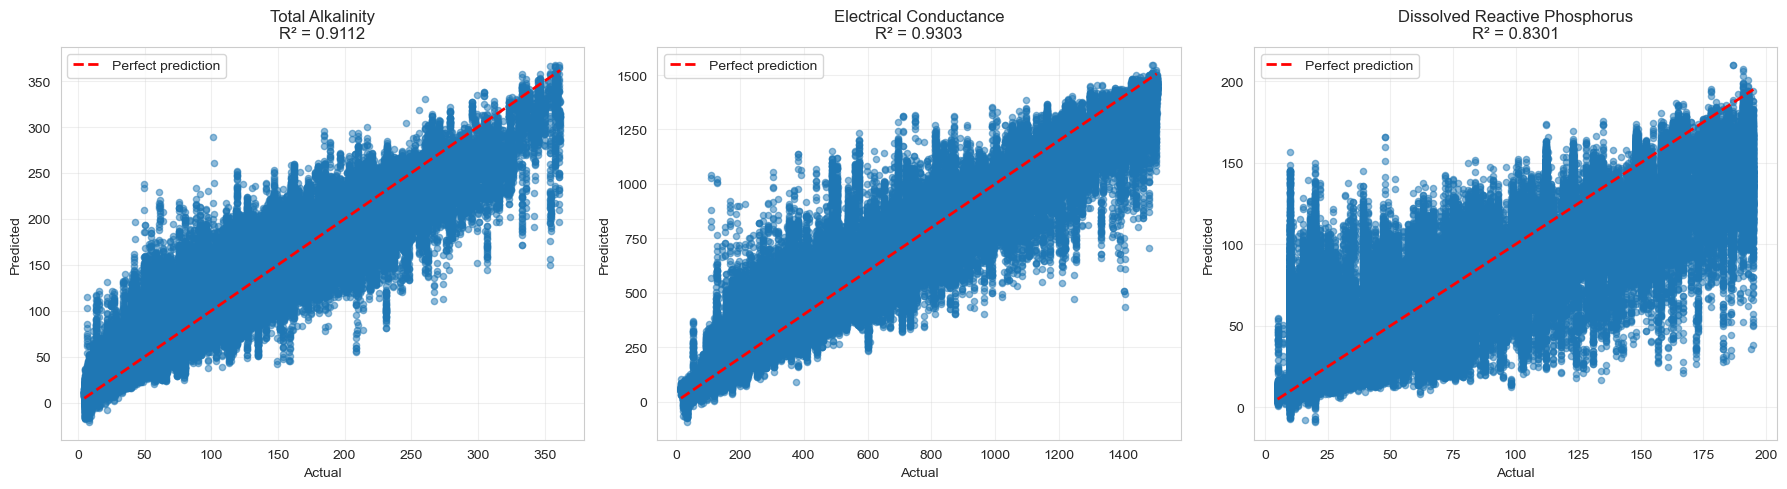

In [14]:
# Prediction vs Actual plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, target in enumerate(targets):
    model = models[target]
    test_pred = model.predict(X_test)
    
    axes[idx].scatter(y_test[target], test_pred, alpha=0.5, s=20)
    axes[idx].plot([y_test[target].min(), y_test[target].max()], 
                   [y_test[target].min(), y_test[target].max()], 
                   'r--', lw=2, label='Perfect prediction')
    axes[idx].set_xlabel('Actual')
    axes[idx].set_ylabel('Predicted')
    axes[idx].set_title(f'{target}\nR² = {metrics[target]["test_r2"]:.4f}')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Feature Importance

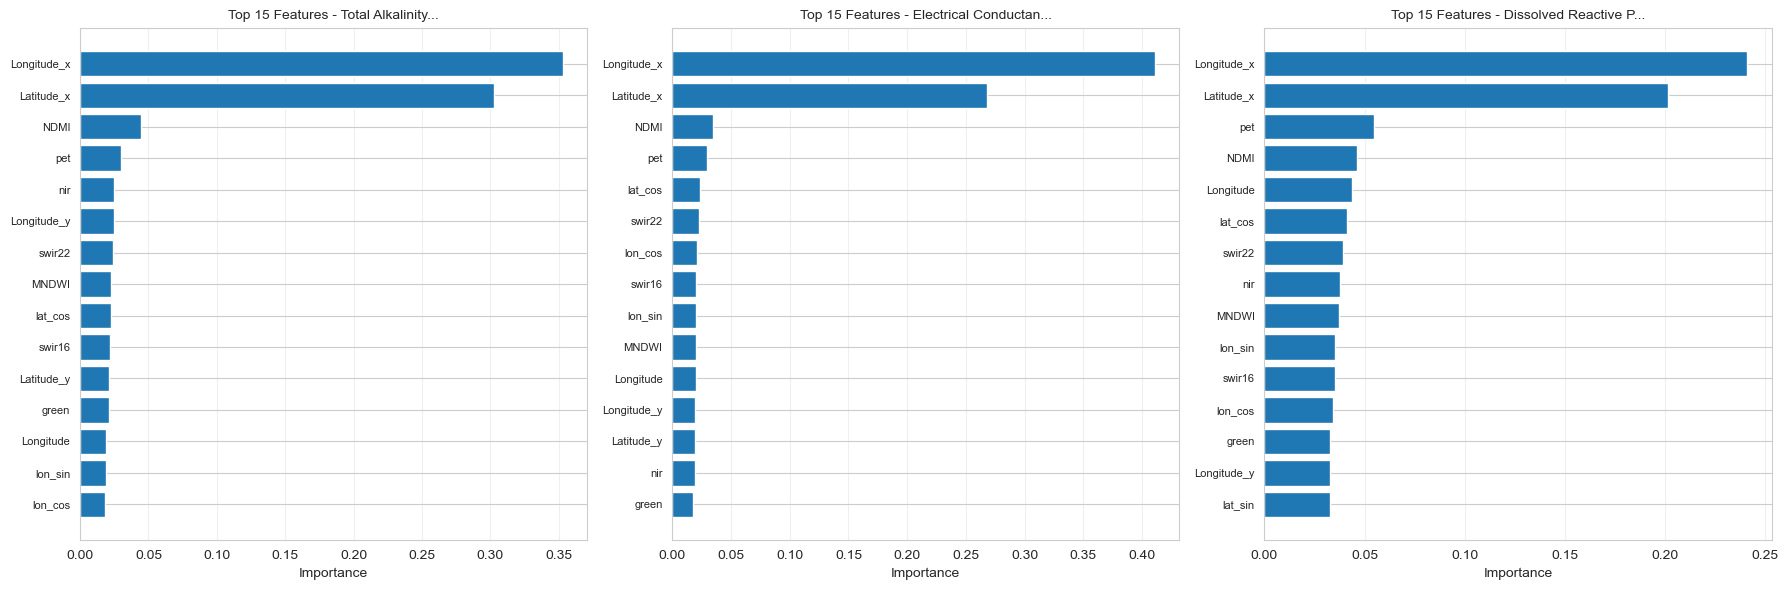

In [15]:
# Feature importance for each model
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, target in enumerate(targets):
    model = models[target]
    
    # Get feature importance
    importance_df = pd.DataFrame({
        'feature': feature_cols,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False).head(15)
    
    # Plot
    axes[idx].barh(range(len(importance_df)), importance_df['importance'])
    axes[idx].set_yticks(range(len(importance_df)))
    axes[idx].set_yticklabels(importance_df['feature'], fontsize=8)
    axes[idx].set_xlabel('Importance')
    axes[idx].set_title(f'Top 15 Features - {target[:20]}...', fontsize=10)
    axes[idx].invert_yaxis()
    axes[idx].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

## 9. Save Trained Models

In [16]:
# Save models
for target, model in models.items():
    # Create safe filename
    safe_target = target.replace(' ', '_').replace('/', '_').replace('(', '').replace(')', '')
    model_path = MODELS_DIR / f'model_{safe_target}.joblib'
    
    # Save model and metadata
    joblib.dump({
        'model': model,
        'feature_names': feature_cols,
        'target_name': target,
        'metrics': metrics[target],
        'params': BEST_XGB_PARAMS
    }, model_path)
    
    print(f"✓ Saved: {model_path}")

print(f"\nAll models saved to: {MODELS_DIR}")

✓ Saved: ..\models\model_Total_Alkalinity.joblib
✓ Saved: ..\models\model_Electrical_Conductance.joblib
✓ Saved: ..\models\model_Dissolved_Reactive_Phosphorus.joblib

All models saved to: ..\models


## Summary

This notebook demonstrated:
- ✅ Data loading and exploration
- ✅ Basic feature engineering (temporal, spectral, spatial)
- ✅ XGBoost model training with optimized hyperparameters
- ✅ Model evaluation (R², RMSE, MAE)
- ✅ Feature importance analysis
- ✅ Model persistence

**Next Steps:**
1. Run `02_feature_engineering.ipynb` for advanced features
2. Run `03_geospatial_features.ipynb` for DEM/slope/landcover
3. Run `04_full_training_pipeline.ipynb` for production training
4. Run `05_submission_generator.ipynb` to generate submission